In [ ]:
import numpy as np;
import pandas as pd;
import matplotlib.pyplot as plt;
import seaborn as sns;

In [47]:
stats = pd.read_csv(r'D:\energy\PV\analysis\APU_Stat_10s.csv');
stats.head()

,Log Type,System,Time Stamp,VL1N/V,VL2N/V,VL3N/V,VL12/V,VL23/V,VL31/V,f/Hz,...,IL3/A,PL1/kW,PL2/kW,PL3/kW,QL1/kvar,QL2/kvar,QL3/kvar,Vdc/V,Idc/A,Pdc/kW
0,APU Stat 10s,APU 1,2026-01-12 00:00:00,375.1977,376.4349,373.0216,652.1350,648.5198,652.0514,49.8521,...,0.5301,0.0,0.0,0.0,0.0,0.0,0.0,0.2878,-0.0764,0.0000
1,APU Stat 10s,APU 2,2026-01-12 00:00:00,375.1977,376.4349,373.0216,652.1350,648.5198,652.0514,49.8521,...,0.4907,0.0,0.0,0.0,0.0,0.0,0.0,-0.2498,0.1267,-0.0000
2,APU Stat 10s,APU 3,2026-01-12 00:00:00,376.5606,373.9651,372.8825,651.0746,649.1744,649.1862,49.8500,...,0.4565,0.0,0.0,0.0,0.0,0.0,0.0,0.4031,0.0396,0.0000
3,APU Stat 10s,APU 4,2026-01-12 00:00:00,376.5606,373.9651,372.8825,651.0746,649.1744,649.1862,49.8500,...,0.5638,0.0,0.0,0.0,0.0,0.0,0.0,-0.3700,0.1145,-0.0001
4,APU Stat 10s,APU 1,2026-01-12 00:01:00,375.1189,376.0260,372.9874,651.8266,647.7210,651.6465,49.8938,...,0.5160,0.0,0.0,0.0,0.0,0.0,0.0,0.3004,-0.1154,-0.0000


In [48]:
stats.info()

<class 'pandas.DataFrame'>
RangeIndex: 338426 entries, 0 to 338425
Data columns (total 22 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Log Type    338426 non-null  str    
 1   System      338426 non-null  str    
 2   Time Stamp  338426 non-null  str    
 3   VL1N/V      338426 non-null  float64
 4   VL2N/V      338426 non-null  float64
 5   VL3N/V      338426 non-null  float64
 6   VL12/V      338426 non-null  float64
 7   VL23/V      338426 non-null  float64
 8   VL31/V      338426 non-null  float64
 9   f/Hz        338426 non-null  float64
 10  IL1/A       338426 non-null  float64
 11  IL2/A       338426 non-null  float64
 12  IL3/A       338426 non-null  float64
 13  PL1/kW      338426 non-null  float64
 14  PL2/kW      338426 non-null  float64
 15  PL3/kW      338426 non-null  float64
 16  QL1/kvar    338426 non-null  float64
 17  QL2/kvar    338426 non-null  float64
 18  QL3/kvar    338426 non-null  float64
 19  Vdc/V       3

In [49]:
stats.describe()

,VL1N/V,VL2N/V,VL3N/V,VL12/V,VL23/V,VL31/V,f/Hz,IL1/A,IL2/A,IL3/A,PL1/kW,PL2/kW,PL3/kW,QL1/kvar,QL2/kvar,QL3/kvar,Vdc/V,Idc/A,Pdc/kW
count,338426.000000,338426.000000,338426.000000,338426.000000,338426.000000,338426.000000,338426.000000,338426.000000,338426.000000,338426.000000,338426.000000,338426.000000,338426.000000,338426.000000,338426.000000,338426.000000,338426.000000,338426.000000,338426.000000
mean,375.181425,373.895040,372.444590,650.162710,646.952324,648.865707,50.107879,278.895995,278.699774,277.724321,100.463587,100.463587,100.463587,5.170247,5.170247,5.170247,565.423392,268.770750,303.338666
std,6.255858,6.631984,6.296272,10.821063,10.999148,10.653120,0.337802,370.391531,370.037896,368.906989,135.322116,135.322116,135.322116,23.805617,23.805617,23.805617,566.352087,366.205351,409.189307
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-13.773900,-13.773900,-13.773900,-93.340500,-93.340500,-93.340500,-0.699500,-2.378400,-24.565100
25%,371.518800,369.442900,368.527300,642.897900,639.523600,642.985600,50.048000,0.495100,0.494700,0.522300,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.077500,0.144300,0.000000
50%,376.805300,375.734300,374.371200,653.587200,650.537800,651.551300,50.126100,0.695550,0.881600,1.041100,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,305.847850,0.415800,0.014700
75%,379.225600,378.385400,376.606400,657.308100,654.389100,655.900500,50.185300,576.536875,576.305800,574.095025,209.862750,209.862750,209.862750,0.414475,0.414475,0.414475,1133.777525,545.714825,633.479250
max,390.946300,390.409300,386.465800,674.687100,669.560000,673.187300,50.465200,1067.424200,1058.939700,1052.501200,385.420200,385.420200,385.420200,153.757500,153.757500,153.757500,1385.762300,1118.525800,1204.325300


In [50]:
stats_apu1 = stats.loc[stats['System'] == 'APU 1']

In [52]:
stats_day1 = stats.loc[(stats['System'] == 'APU 1') & (stats['Time Stamp'].str.startswith('2026-01-12'))]


In [53]:
stats_day1.info()

<class 'pandas.DataFrame'>
RangeIndex: 1440 entries, 0 to 5756
Data columns (total 22 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Log Type    1440 non-null   str    
 1   System      1440 non-null   str    
 2   Time Stamp  1440 non-null   str    
 3   VL1N/V      1440 non-null   float64
 4   VL2N/V      1440 non-null   float64
 5   VL3N/V      1440 non-null   float64
 6   VL12/V      1440 non-null   float64
 7   VL23/V      1440 non-null   float64
 8   VL31/V      1440 non-null   float64
 9   f/Hz        1440 non-null   float64
 10  IL1/A       1440 non-null   float64
 11  IL2/A       1440 non-null   float64
 12  IL3/A       1440 non-null   float64
 13  PL1/kW      1440 non-null   float64
 14  PL2/kW      1440 non-null   float64
 15  PL3/kW      1440 non-null   float64
 16  QL1/kvar    1440 non-null   float64
 17  QL2/kvar    1440 non-null   float64
 18  QL3/kvar    1440 non-null   float64
 19  Vdc/V       1440 non-null   float64
 2

In [54]:
stats_apu1.info()

<class 'pandas.DataFrame'>
Index: 86751 entries, 0 to 338422
Data columns (total 22 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Log Type    86751 non-null  str    
 1   System      86751 non-null  str    
 2   Time Stamp  86751 non-null  str    
 3   VL1N/V      86751 non-null  float64
 4   VL2N/V      86751 non-null  float64
 5   VL3N/V      86751 non-null  float64
 6   VL12/V      86751 non-null  float64
 7   VL23/V      86751 non-null  float64
 8   VL31/V      86751 non-null  float64
 9   f/Hz        86751 non-null  float64
 10  IL1/A       86751 non-null  float64
 11  IL2/A       86751 non-null  float64
 12  IL3/A       86751 non-null  float64
 13  PL1/kW      86751 non-null  float64
 14  PL2/kW      86751 non-null  float64
 15  PL3/kW      86751 non-null  float64
 16  QL1/kvar    86751 non-null  float64
 17  QL2/kvar    86751 non-null  float64
 18  QL3/kvar    86751 non-null  float64
 19  Vdc/V       86751 non-null  float64
 20 

In [55]:
apu1 = stats_apu1.copy()

In [62]:
stats_apu1.describe()

,VL1N/V,VL2N/V,VL3N/V,VL12/V,VL23/V,VL31/V,f/Hz,IL1/A,IL2/A,IL3/A,PL1/kW,PL2/kW,PL3/kW,QL1/kvar,QL2/kvar,QL3/kvar,Vdc/V,Idc/A,Pdc/kW
count,86751.000000,86751.000000,86751.000000,86751.000000,86751.000000,86751.000000,86751.000000,86751.000000,86751.000000,86751.000000,86751.000000,86751.000000,86751.000000,86751.000000,86751.000000,86751.000000,86751.000000,86751.000000,86751.000000
mean,375.435164,374.115527,372.807523,650.728187,646.558090,650.848947,50.108873,281.466655,278.249351,276.355667,100.704790,100.704790,100.704790,5.094398,5.094398,5.094398,563.271010,269.973136,303.777746
std,6.012652,6.311221,6.058852,10.257681,10.584536,9.953190,0.225444,373.027060,368.982820,366.006205,135.274979,135.274979,135.274979,23.639471,23.639471,23.639471,564.571259,367.454871,408.726781
min,61.509700,65.679400,69.052700,165.477200,118.409500,133.926700,14.955000,0.470600,0.354200,0.470200,-1.286500,-1.286500,-1.286500,-92.563800,-92.563800,-92.563800,0.088700,-0.708400,-1.805100
25%,371.587850,369.842800,368.737350,643.431200,638.802900,644.559300,50.047800,0.503000,0.424000,0.528800,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.296900,0.046700,0.000000
50%,376.898100,376.153700,374.791600,654.113000,650.186400,653.993000,50.125800,0.549900,0.654900,0.645200,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,283.095100,0.285200,0.003000
75%,379.428550,378.651100,376.964350,657.836050,654.050750,657.684650,50.185000,591.985500,585.756300,581.639550,214.348700,214.348700,214.348700,0.168600,0.168600,0.168600,1128.046850,556.161750,646.312800
max,390.946300,387.819100,386.465800,674.687100,668.989800,673.187300,50.465200,1062.989000,1049.646000,1043.169000,382.598600,382.598600,382.598600,153.425500,153.425500,153.425500,1376.488200,1092.250200,1174.128800


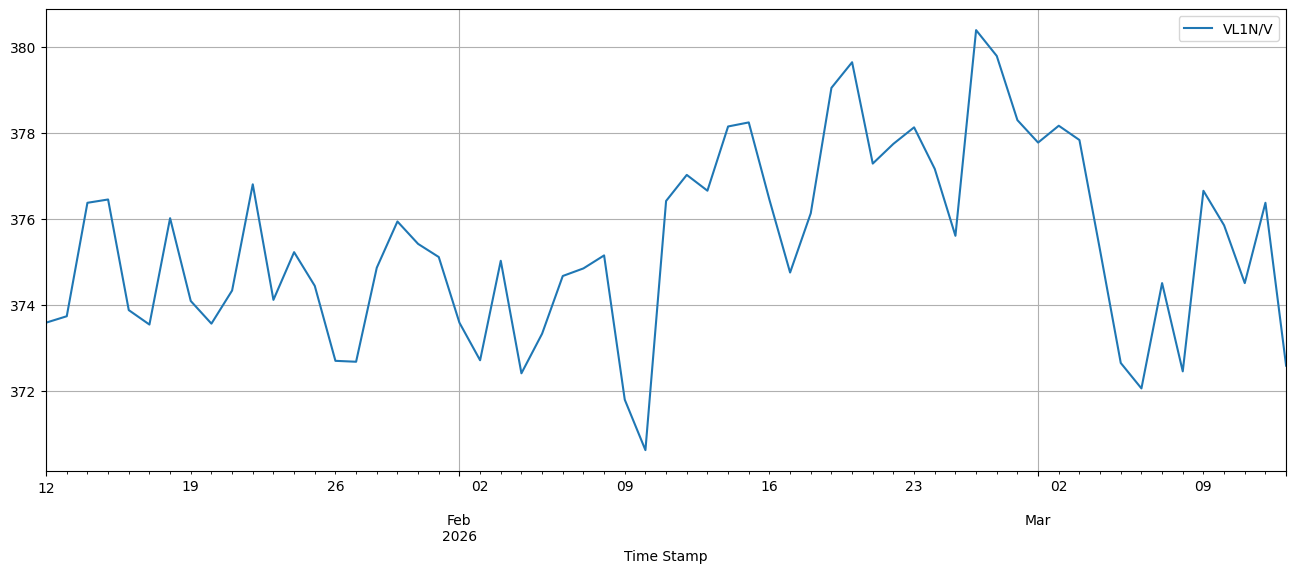

In [56]:
# 1. Đảm bảo cột Time Stamp là kiểu datetime và đặt làm Index
apu1['Time Stamp'] = pd.to_datetime(apu1['Time Stamp'])
apu1.set_index('Time Stamp', inplace=True)

# 2. Sau đó mới chạy lại lệnh vẽ biểu đồ
cols_to_plot = ['VL1N/V']
apu1[cols_to_plot].resample('D').mean().plot(subplots=True, figsize=(16, 6), grid=True)
plt.show()


Điện áp thấp nhất vào 11/2

In [66]:
y1_apu1 = stats_day1.copy()

In [71]:
stats_day1.describe()

,VL1N/V,VL2N/V,VL3N/V,VL12/V,VL23/V,VL31/V,f/Hz,IL1/A,IL2/A,IL3/A,PL1/kW,PL2/kW,PL3/kW,QL1/kvar,QL2/kvar,QL3/kvar,Vdc/V,Idc/A,Pdc/kW
count,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000
mean,373.587647,373.970972,371.110782,648.704358,644.576423,648.838532,50.102045,292.011118,288.663866,286.421428,103.082102,103.082102,103.082102,8.825198,8.825198,8.825198,546.846955,280.379692,311.063717
std,5.307617,5.596552,5.513330,9.294376,9.573157,9.123541,0.094842,386.723044,382.622306,379.220435,140.652134,140.652134,140.652134,31.229336,31.229336,31.229336,556.393535,385.668617,424.791003
min,357.758700,358.834600,355.146100,622.809500,619.187500,622.437300,49.681600,0.481400,0.392100,0.502900,-1.121000,-1.121000,-1.121000,-62.694500,-62.694500,-62.694500,0.277200,-0.199700,-0.230100
25%,371.004425,370.248025,367.887100,643.418150,638.455750,644.209625,50.044150,0.509175,0.442400,0.530200,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.298500,-0.077675,0.000000
50%,375.330750,376.264450,372.989300,652.304300,648.372950,651.856400,50.117050,0.527900,0.530800,0.587350,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.933900,0.116750,0.000100
75%,377.695150,378.459300,375.514300,656.084850,652.443950,655.846300,50.172850,725.551900,718.210875,711.571600,263.057350,263.057350,263.057350,7.244375,7.244375,7.244375,1101.500400,708.481875,795.424100
max,380.794600,381.732600,378.881300,660.486600,657.336500,660.953900,50.404500,957.564800,948.825900,940.362300,344.663700,344.663700,344.663700,84.967300,84.967300,84.967300,1270.800000,952.586100,1046.519200


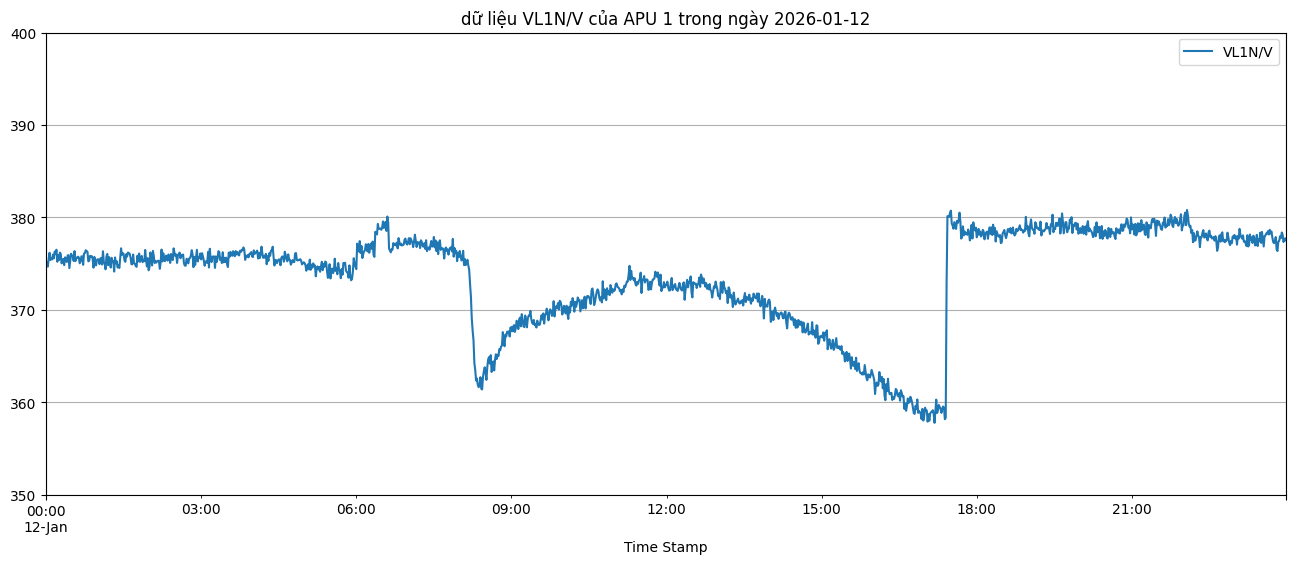

In [67]:
# 1. Đảm bảo cột Time Stamp là kiểu datetime và đặt làm Index
y1_apu1['Time Stamp'] = pd.to_datetime(y1_apu1['Time Stamp'])
y1_apu1.set_index('Time Stamp', inplace=True)

# 2. Sau đó mới chạy lại lệnh vẽ biểu đồ
cols_to_plot = ['VL1N/V']
y1_apu1[cols_to_plot].plot(subplots=True, figsize=(16, 6), grid=True)
#plt.ylim(bottom=0)
plt.title("dữ liệu VL1N/V của APU 1 trong ngày 2026-01-12")
plt.ylim(350,400)
plt.show()


In [68]:
stats_day1 = stats.loc[(stats['System'] == 'APU 1') & (stats['Time Stamp'].str.startswith('2026-01-12'))]


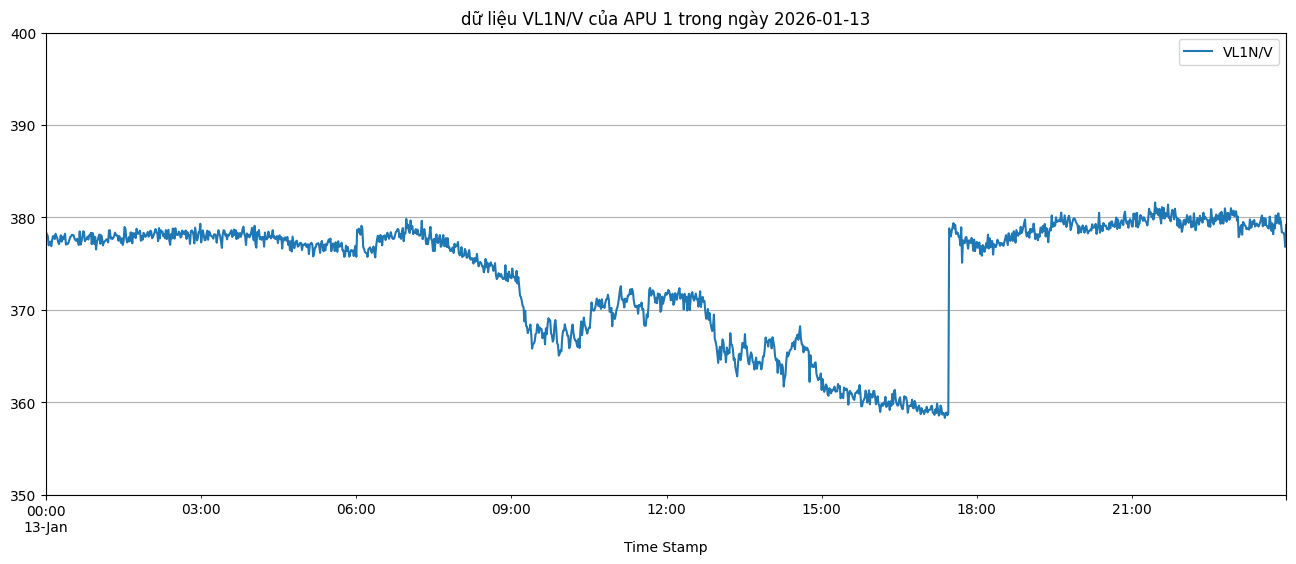

In [69]:
stats_day2 = stats.loc[(stats['System'] == 'APU 1') & (stats['Time Stamp'].str.startswith('2026-01-13'))]
s2_apu1 = stats_day2.copy()
# 1. Đảm bảo cột Time Stamp là kiểu datetime và đặt làm Index
s2_apu1['Time Stamp'] = pd.to_datetime(s2_apu1['Time Stamp'])
s2_apu1.set_index('Time Stamp', inplace=True)

# 2. Sau đó mới chạy lại lệnh vẽ biểu đồ
cols_to_plot = ['VL1N/V']
s2_apu1[cols_to_plot].plot(subplots=True, figsize=(16, 6), grid=True)
#plt.ylim(bottom=0)
plt.title("dữ liệu VL1N/V của APU 1 trong ngày 2026-01-13")
plt.ylim(350,400)
plt.show()


In [72]:
stats_day2.describe()

,VL1N/V,VL2N/V,VL3N/V,VL12/V,VL23/V,VL31/V,f/Hz,IL1/A,IL2/A,IL3/A,PL1/kW,PL2/kW,PL3/kW,QL1/kvar,QL2/kvar,QL3/kvar,Vdc/V,Idc/A,Pdc/kW
count,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000
mean,373.736910,374.197724,371.275179,649.013825,644.981194,649.096387,50.120148,224.580916,221.823978,220.296368,77.521926,77.521926,77.521926,-1.316756,-1.316756,-1.316756,554.230376,207.197057,233.724840
std,6.493173,6.780998,6.747161,11.344654,11.647795,11.203496,0.101229,321.910185,318.339554,315.523022,117.288395,117.288395,117.288395,24.283980,24.283980,24.283980,563.233928,316.706305,354.190713
min,358.292000,358.836800,355.394300,623.522500,619.642900,622.973900,49.795300,0.479500,0.399700,0.506700,-1.045400,-1.045400,-1.045400,-59.698900,-59.698900,-59.698900,0.281000,-0.034400,-0.115100
25%,369.166325,368.628000,366.061950,640.443600,635.421200,641.407900,50.060225,0.497000,0.457100,0.545650,0.000000,0.000000,0.000000,-5.952375,-5.952375,-5.952375,0.306000,0.052950,0.000000
50%,377.184350,378.010550,374.929600,655.213500,651.473450,655.226000,50.133150,0.509950,0.498250,0.590350,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.167050,0.098350,0.000200
75%,378.406700,379.218650,376.242650,657.248650,653.508600,657.045625,50.194250,333.577250,329.578400,327.707675,117.427750,117.427750,117.427750,0.000000,0.000000,0.000000,1136.790350,308.219175,352.565400
max,381.609700,382.352600,379.356200,662.043800,658.184200,661.871800,50.387400,1003.129700,990.612100,981.014900,363.963500,363.963500,363.963500,73.182100,73.182100,73.182100,1241.587800,1004.327800,1099.325000


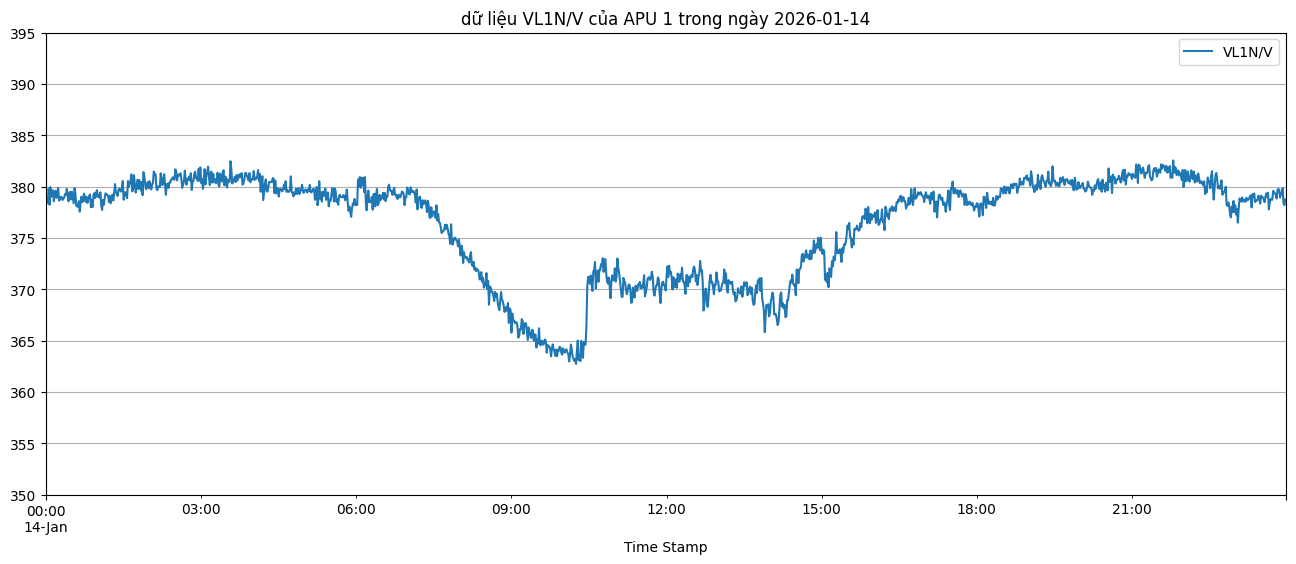

In [81]:
stats_day3 = stats.loc[(stats['System'] == 'APU 1') & (stats['Time Stamp'].str.startswith('2026-01-14'))]
s3_apu1 = stats_day3.copy()
# 1. Đảm bảo cột Time Stamp là kiểu datetime và đặt làm Index
s3_apu1['Time Stamp'] = pd.to_datetime(s3_apu1['Time Stamp'])
s3_apu1.set_index('Time Stamp', inplace=True)

# 2. Sau đó mới chạy lại lệnh vẽ biểu đồ
cols_to_plot = ['VL1N/V']
s3_apu1[cols_to_plot].plot(subplots=True, figsize=(16, 6), grid=True)
#plt.ylim(bottom=0)
plt.title("dữ liệu VL1N/V của APU 1 trong ngày 2026-01-14")
plt.ylim(350,395)
plt.show()


In [74]:
stats_day26 = stats.loc[(stats['System'] == 'APU 1') & (stats['Time Stamp'].str.startswith('2026-01-26'))]


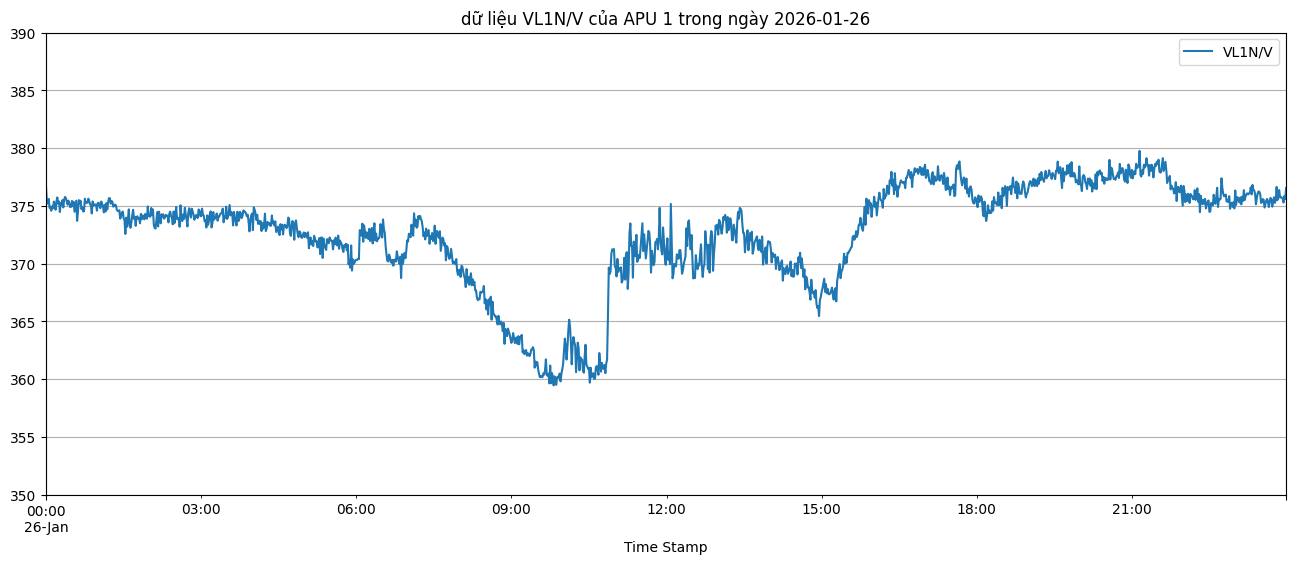

In [80]:
s26_apu1 = stats_day26.copy()
# 1. Đảm bảo cột Time Stamp là kiểu datetime và đặt làm Index
s26_apu1['Time Stamp'] = pd.to_datetime(s26_apu1['Time Stamp'])
s26_apu1.set_index('Time Stamp', inplace=True)

# 2. Sau đó mới chạy lại lệnh vẽ biểu đồ
cols_to_plot = ['VL1N/V']
s26_apu1[cols_to_plot].plot(subplots=True, figsize=(16, 6), grid=True)
#plt.ylim(bottom=0)
plt.title("dữ liệu VL1N/V của APU 1 trong ngày 2026-01-26")
plt.ylim(350,390)
plt.show()


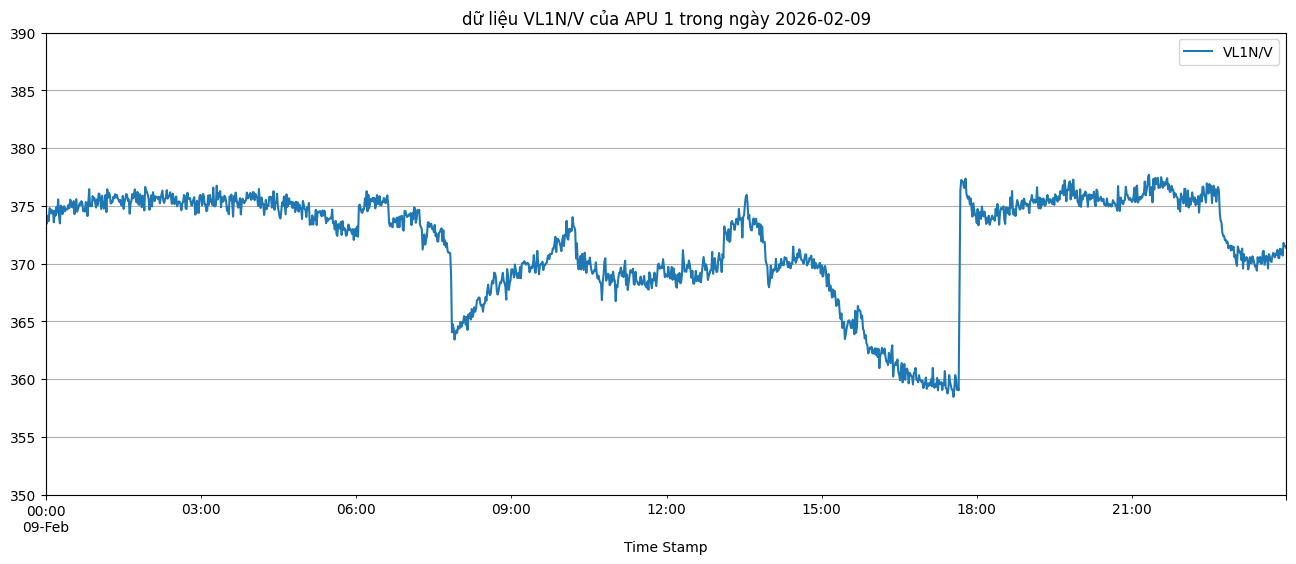

In [88]:
stats_day9 = stats.loc[(stats['System'] == 'APU 1') & (stats['Time Stamp'].str.startswith('2026-02-09'))]
s9_apu1 = stats_day9.copy()
# 1. Đảm bảo cột Time Stamp là kiểu datetime và đặt làm Index
s9_apu1['Time Stamp'] = pd.to_datetime(s9_apu1['Time Stamp'])
s9_apu1.set_index('Time Stamp', inplace=True)

# 2. Sau đó mới chạy lại lệnh vẽ biểu đồ
cols_to_plot = ['VL1N/V']
s9_apu1[cols_to_plot].plot(subplots=True, figsize=(16, 6), grid=True)
#plt.ylim(bottom=0)
plt.title("dữ liệu VL1N/V của APU 1 trong ngày 2026-02-09")
plt.ylim(350,390)
plt.show()


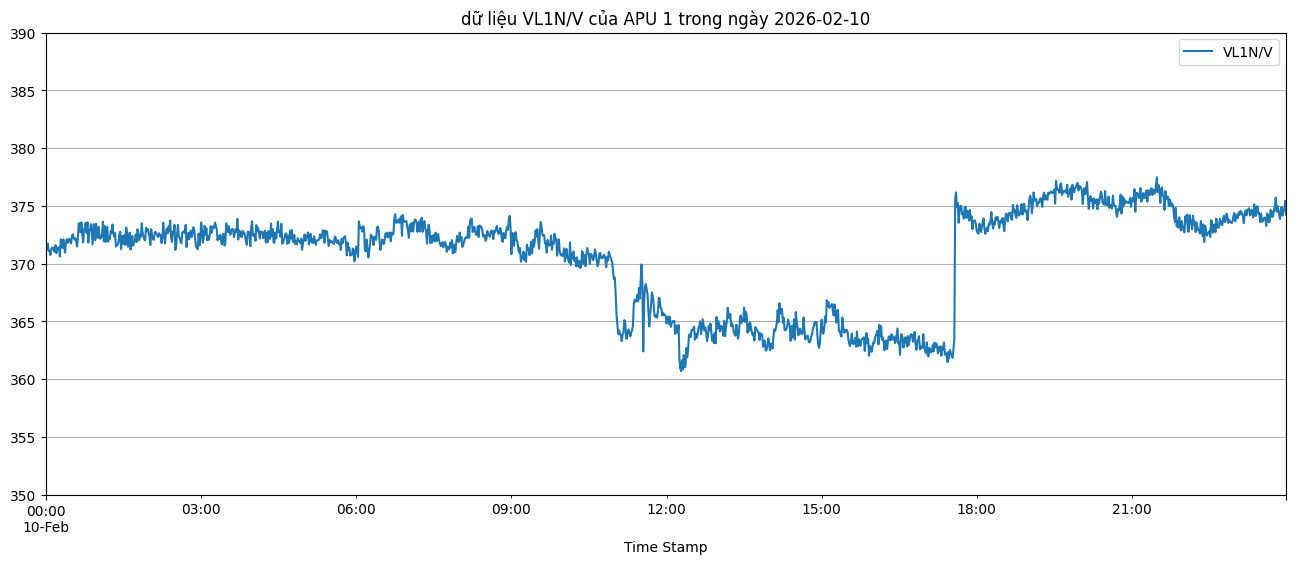

In [90]:
stats_day10 = stats.loc[(stats['System'] == 'APU 1') & (stats['Time Stamp'].str.startswith('2026-02-10'))]
s10_apu1 = stats_day10.copy()
# 1. Đảm bảo cột Time Stamp là kiểu datetime và đặt làm Index
s10_apu1['Time Stamp'] = pd.to_datetime(s10_apu1['Time Stamp'])
s10_apu1.set_index('Time Stamp', inplace=True)

# 2. Sau đó mới chạy lại lệnh vẽ biểu đồ
cols_to_plot = ['VL1N/V']
s10_apu1[cols_to_plot].plot(subplots=True, figsize=(16, 6), grid=True)
#plt.ylim(bottom=0)
plt.title("dữ liệu VL1N/V của APU 1 trong ngày 2026-02-10")
plt.ylim(350,390)
plt.show()


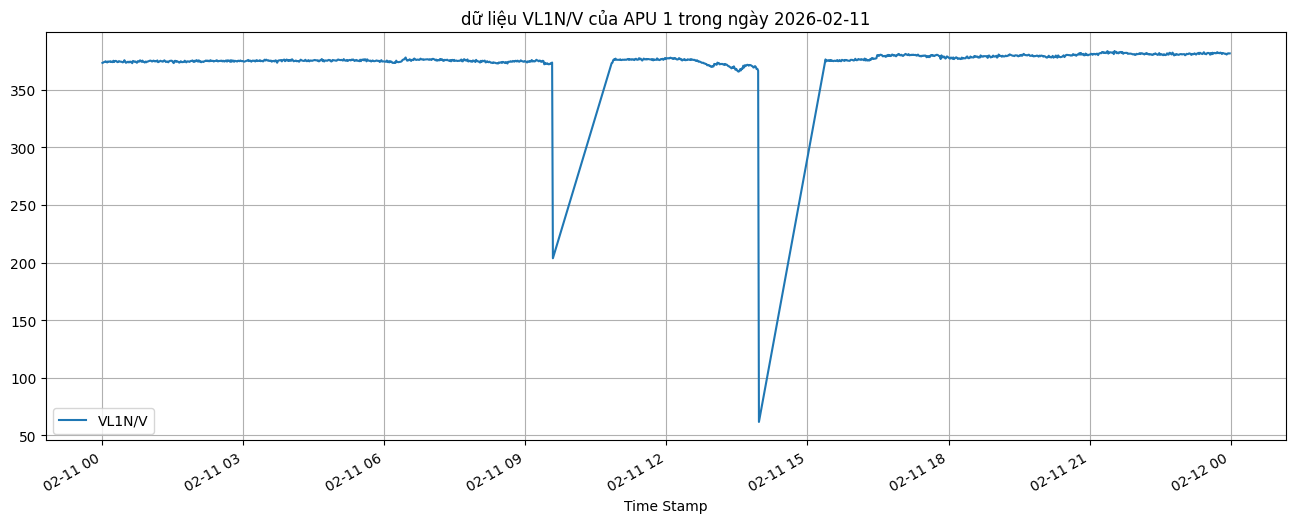

In [98]:
stats_day11 = stats.loc[(stats['System'] == 'APU 1') & (stats['Time Stamp'].str.startswith('2026-02-11'))]
s11_apu1 = stats_day11.copy()
# 1. Đảm bảo cột Time Stamp là kiểu datetime và đặt làm Index
s11_apu1['Time Stamp'] = pd.to_datetime(s11_apu1['Time Stamp'])
s11_apu1.set_index('Time Stamp', inplace=True)

# 2. Sau đó mới chạy lại lệnh vẽ biểu đồ
cols_to_plot = ['VL1N/V']
s11_apu1[cols_to_plot].plot(subplots=True, figsize=(16, 6), grid=True)
#plt.ylim(bottom=0)
plt.title("dữ liệu VL1N/V của APU 1 trong ngày 2026-02-11")
#plt.ylim(0,390)
plt.show()


##Du lieu bat thuong, phat hien loi dot ngot

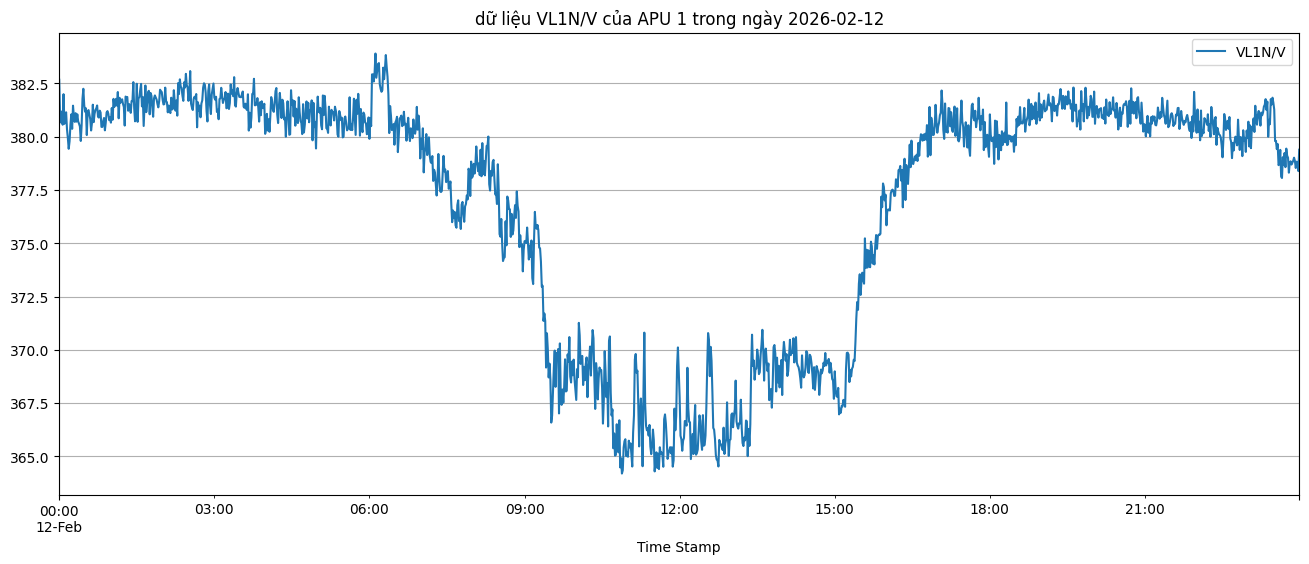

In [99]:
stats_day12 = stats.loc[(stats['System'] == 'APU 1') & (stats['Time Stamp'].str.startswith('2026-02-12'))]
s12_apu1 = stats_day12.copy()
# 1. Đảm bảo cột Time Stamp là kiểu datetime và đặt làm Index
s12_apu1['Time Stamp'] = pd.to_datetime(s12_apu1['Time Stamp'])
s12_apu1.set_index('Time Stamp', inplace=True)

# 2. Sau đó mới chạy lại lệnh vẽ biểu đồ
cols_to_plot = ['VL1N/V']
s12_apu1[cols_to_plot].plot(subplots=True, figsize=(16, 6), grid=True)
#plt.ylim(bottom=0)
plt.title("dữ liệu VL1N/V của APU 1 trong ngày 2026-02-12")
#plt.ylim(350,390)
plt.show()


In [82]:
stats_day26.describe()

,VL1N/V,VL2N/V,VL3N/V,VL12/V,VL23/V,VL31/V,f/Hz,IL1/A,IL2/A,IL3/A,PL1/kW,PL2/kW,PL3/kW,QL1/kvar,QL2/kvar,QL3/kvar,Vdc/V,Idc/A,Pdc/kW
count,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000
mean,372.699690,373.016592,370.327017,646.992183,643.158015,647.508471,50.117105,314.611060,310.982528,308.626784,112.776068,112.776068,112.776068,12.193525,12.193525,12.193525,553.236667,305.290372,340.222568
std,4.435416,4.845090,4.706117,7.896295,8.212527,7.699038,0.105020,402.032166,397.617748,394.153838,144.503042,144.503042,144.503042,25.442008,25.442008,25.442008,560.532390,394.772866,436.496768
min,359.448000,359.110900,356.339100,624.264200,619.869800,625.381500,49.783200,0.484300,0.379300,0.518100,-0.687400,-0.687400,-0.687400,-7.947300,-7.947300,-7.947300,0.267900,-0.128000,-0.001800
25%,370.623775,370.643625,368.024225,643.002350,639.075950,643.851900,50.043900,0.500400,0.435300,0.574275,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.303850,0.047300,0.000000
50%,373.772700,374.556850,371.595500,649.543150,645.911100,649.434500,50.138900,0.519600,0.504150,0.620000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,15.909100,0.101100,0.000550
75%,375.765025,376.457750,373.592450,652.396750,648.786500,652.847625,50.196450,765.648025,756.746600,751.224975,276.910250,276.910250,276.910250,11.639400,11.639400,11.639400,1111.210700,747.517750,835.360625
max,379.753900,380.644600,377.432200,657.749600,654.026400,658.340100,50.365200,1020.856700,1008.640300,999.293400,368.591600,368.591600,368.591600,108.584900,108.584900,108.584900,1217.097200,1009.734800,1125.727000


In [59]:
stats_day1.describe()

,VL1N/V,VL2N/V,VL3N/V,VL12/V,VL23/V,VL31/V,f/Hz,IL1/A,IL2/A,IL3/A,PL1/kW,PL2/kW,PL3/kW,QL1/kvar,QL2/kvar,QL3/kvar,Vdc/V,Idc/A,Pdc/kW
count,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000
mean,373.587647,373.970972,371.110782,648.704358,644.576423,648.838532,50.102045,292.011118,288.663866,286.421428,103.082102,103.082102,103.082102,8.825198,8.825198,8.825198,546.846955,280.379692,311.063717
std,5.307617,5.596552,5.513330,9.294376,9.573157,9.123541,0.094842,386.723044,382.622306,379.220435,140.652134,140.652134,140.652134,31.229336,31.229336,31.229336,556.393535,385.668617,424.791003
min,357.758700,358.834600,355.146100,622.809500,619.187500,622.437300,49.681600,0.481400,0.392100,0.502900,-1.121000,-1.121000,-1.121000,-62.694500,-62.694500,-62.694500,0.277200,-0.199700,-0.230100
25%,371.004425,370.248025,367.887100,643.418150,638.455750,644.209625,50.044150,0.509175,0.442400,0.530200,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.298500,-0.077675,0.000000
50%,375.330750,376.264450,372.989300,652.304300,648.372950,651.856400,50.117050,0.527900,0.530800,0.587350,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.933900,0.116750,0.000100
75%,377.695150,378.459300,375.514300,656.084850,652.443950,655.846300,50.172850,725.551900,718.210875,711.571600,263.057350,263.057350,263.057350,7.244375,7.244375,7.244375,1101.500400,708.481875,795.424100
max,380.794600,381.732600,378.881300,660.486600,657.336500,660.953900,50.404500,957.564800,948.825900,940.362300,344.663700,344.663700,344.663700,84.967300,84.967300,84.967300,1270.800000,952.586100,1046.519200


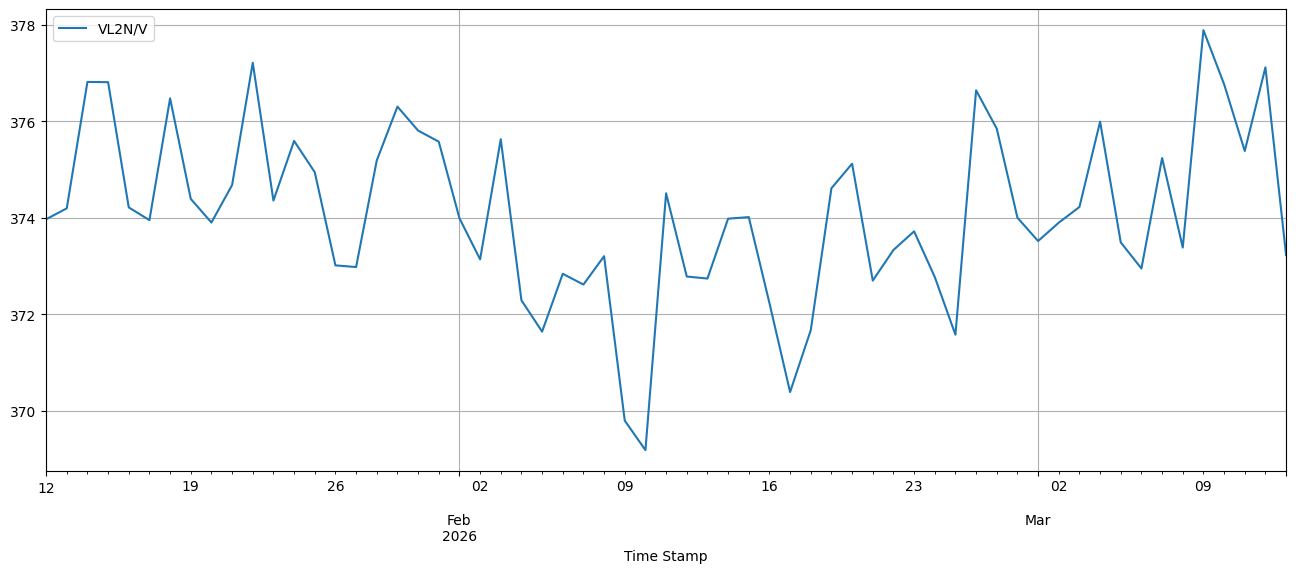

In [87]:


# 2. Sau đó mới chạy lại lệnh vẽ biểu đồ
cols_to_plot = ['VL2N/V']
apu1[cols_to_plot].resample('D').mean().plot(subplots=True, figsize=(16, 6), grid=True)
plt.show()


In [100]:
stats_day10.describe()

,VL1N/V,VL2N/V,VL3N/V,VL12/V,VL23/V,VL31/V,f/Hz,IL1/A,IL2/A,IL3/A,PL1/kW,PL2/kW,PL3/kW,QL1/kvar,QL2/kvar,QL3/kvar,Vdc/V,Idc/A,Pdc/kW
count,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000
mean,370.623090,369.192747,370.973989,644.329075,640.835581,644.711695,50.107524,148.747801,146.868218,146.636222,52.895078,52.895078,52.895078,-2.712578,-2.712578,-2.712578,583.180170,136.224675,159.050176
std,4.280109,4.374845,4.285410,7.383278,7.338951,7.251511,0.093223,204.933305,202.656889,201.894760,74.269631,74.269631,74.269631,5.303116,5.303116,5.303116,568.299697,190.935510,223.939859
min,360.672800,359.115300,361.602200,627.493600,624.895700,628.584000,49.787500,0.490000,0.373200,0.491200,-1.286500,-1.286500,-1.286500,-17.620300,-17.620300,-17.620300,0.256600,-0.708400,-0.854200
25%,366.161575,364.146350,366.172775,635.899725,632.109425,636.796325,50.050375,0.516800,0.408700,0.517675,0.000000,0.000000,0.000000,-7.411650,-7.411650,-7.411650,0.284000,-0.004375,0.000000
50%,372.191000,370.884550,372.417950,647.378650,643.642050,647.441100,50.118050,2.071600,1.113100,2.052550,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,905.421750,0.047050,0.000150
75%,373.522325,372.140375,373.815100,649.074000,645.807475,649.543550,50.174850,288.130775,284.666200,284.407825,104.286500,104.286500,104.286500,0.000000,0.000000,0.000000,1155.746350,269.852125,313.735750
max,377.463200,375.611000,377.624000,654.847300,651.457900,655.429700,50.397900,1049.348300,1037.144200,1031.454300,380.809700,380.809700,380.809700,42.943200,42.943200,42.943200,1355.579700,981.869900,1169.357700


In [101]:
stats_apu1.describe()

,VL1N/V,VL2N/V,VL3N/V,VL12/V,VL23/V,VL31/V,f/Hz,IL1/A,IL2/A,IL3/A,PL1/kW,PL2/kW,PL3/kW,QL1/kvar,QL2/kvar,QL3/kvar,Vdc/V,Idc/A,Pdc/kW
count,86751.000000,86751.000000,86751.000000,86751.000000,86751.000000,86751.000000,86751.000000,86751.000000,86751.000000,86751.000000,86751.000000,86751.000000,86751.000000,86751.000000,86751.000000,86751.000000,86751.000000,86751.000000,86751.000000
mean,375.435164,374.115527,372.807523,650.728187,646.558090,650.848947,50.108873,281.466655,278.249351,276.355667,100.704790,100.704790,100.704790,5.094398,5.094398,5.094398,563.271010,269.973136,303.777746
std,6.012652,6.311221,6.058852,10.257681,10.584536,9.953190,0.225444,373.027060,368.982820,366.006205,135.274979,135.274979,135.274979,23.639471,23.639471,23.639471,564.571259,367.454871,408.726781
min,61.509700,65.679400,69.052700,165.477200,118.409500,133.926700,14.955000,0.470600,0.354200,0.470200,-1.286500,-1.286500,-1.286500,-92.563800,-92.563800,-92.563800,0.088700,-0.708400,-1.805100
25%,371.587850,369.842800,368.737350,643.431200,638.802900,644.559300,50.047800,0.503000,0.424000,0.528800,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.296900,0.046700,0.000000
50%,376.898100,376.153700,374.791600,654.113000,650.186400,653.993000,50.125800,0.549900,0.654900,0.645200,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,283.095100,0.285200,0.003000
75%,379.428550,378.651100,376.964350,657.836050,654.050750,657.684650,50.185000,591.985500,585.756300,581.639550,214.348700,214.348700,214.348700,0.168600,0.168600,0.168600,1128.046850,556.161750,646.312800
max,390.946300,387.819100,386.465800,674.687100,668.989800,673.187300,50.465200,1062.989000,1049.646000,1043.169000,382.598600,382.598600,382.598600,153.425500,153.425500,153.425500,1376.488200,1092.250200,1174.128800


In [102]:
stats_day11.describe()

,VL1N/V,VL2N/V,VL3N/V,VL12/V,VL23/V,VL31/V,f/Hz,IL1/A,IL2/A,IL3/A,PL1/kW,PL2/kW,PL3/kW,QL1/kvar,QL2/kvar,QL3/kvar,Vdc/V,Idc/A,Pdc/kW
count,1282.000000,1282.000000,1282.000000,1282.000000,1282.000000,1282.000000,1282.000000,1282.000000,1282.000000,1282.000000,1282.000000,1282.000000,1282.000000,1282.000000,1282.000000,1282.000000,1282.000000,1282.000000,1282.000000
mean,376.418026,374.508811,374.965118,652.642449,649.061094,652.783686,50.059413,55.735245,54.941156,54.873547,19.660424,19.660424,19.660424,-0.984731,-0.984731,-0.984731,401.650242,50.802837,58.457389
std,10.478649,10.059878,9.926057,15.869902,17.193958,16.890760,1.120970,115.871714,114.566825,114.030945,42.305731,42.305731,42.305731,2.572843,2.572843,2.572843,533.267795,109.369409,127.165426
min,61.509700,65.679400,69.052700,165.477200,118.409500,133.926700,14.955000,0.480500,0.370600,0.476000,-1.216500,-1.216500,-1.216500,-26.384500,-26.384500,-26.384500,0.088700,-0.517700,-0.531400
25%,374.915700,373.468275,374.696675,651.575850,647.981300,651.623125,50.039800,0.515100,0.414225,0.516525,0.000000,0.000000,0.000000,-0.057825,-0.057825,-0.057825,0.285600,-0.052775,0.000000
50%,376.037650,374.528450,375.556800,652.974000,649.418550,653.021200,50.115700,0.523900,0.432300,0.529550,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.296950,-0.008000,0.000000
75%,379.504325,376.691225,376.429200,655.562700,652.100150,655.838925,50.166875,75.179600,73.787875,73.997025,24.758950,24.758950,24.758950,0.000000,0.000000,0.000000,1118.018850,64.534050,71.873325
max,383.760200,379.726900,379.664200,661.428600,657.592000,661.583600,50.428500,1053.645300,1040.222000,1033.237800,381.824000,381.824000,381.824000,3.031500,3.031500,3.031500,1290.861000,943.446600,1157.451700


Khao sat IL1/A, PL1/kW, QL1/kwar, Vdc/V, Idc/A, Pdc/kW

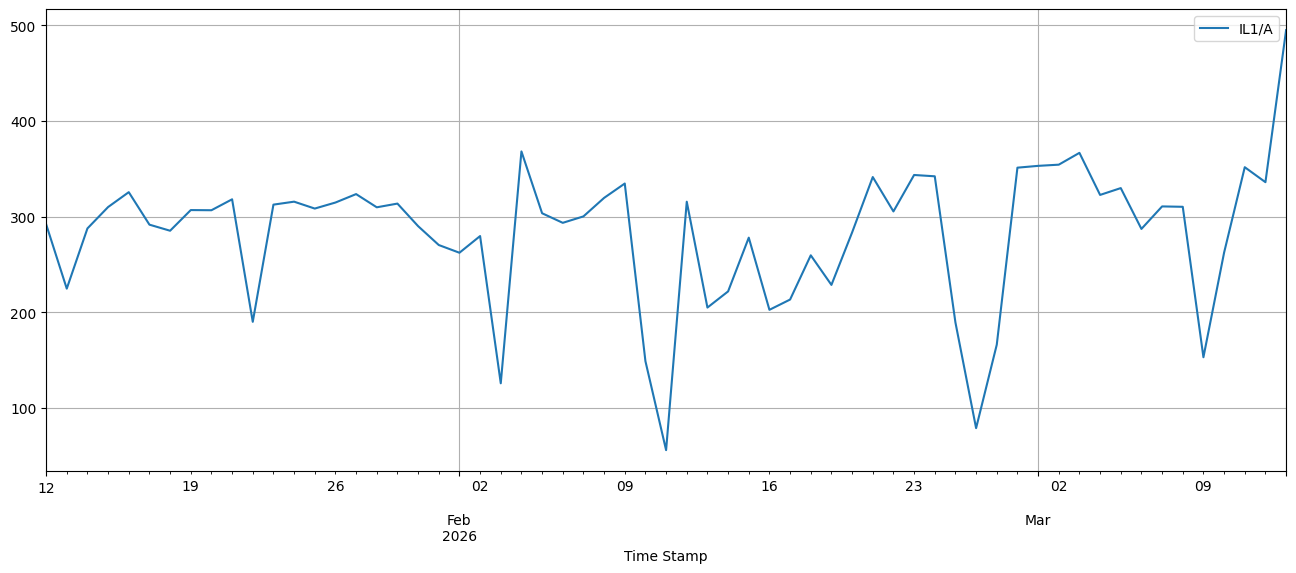

In [103]:


# 2. Sau đó mới chạy lại lệnh vẽ biểu đồ
cols_to_plot = ['IL1/A']
apu1[cols_to_plot].resample('D').mean().plot(subplots=True, figsize=(16, 6), grid=True)
plt.show()


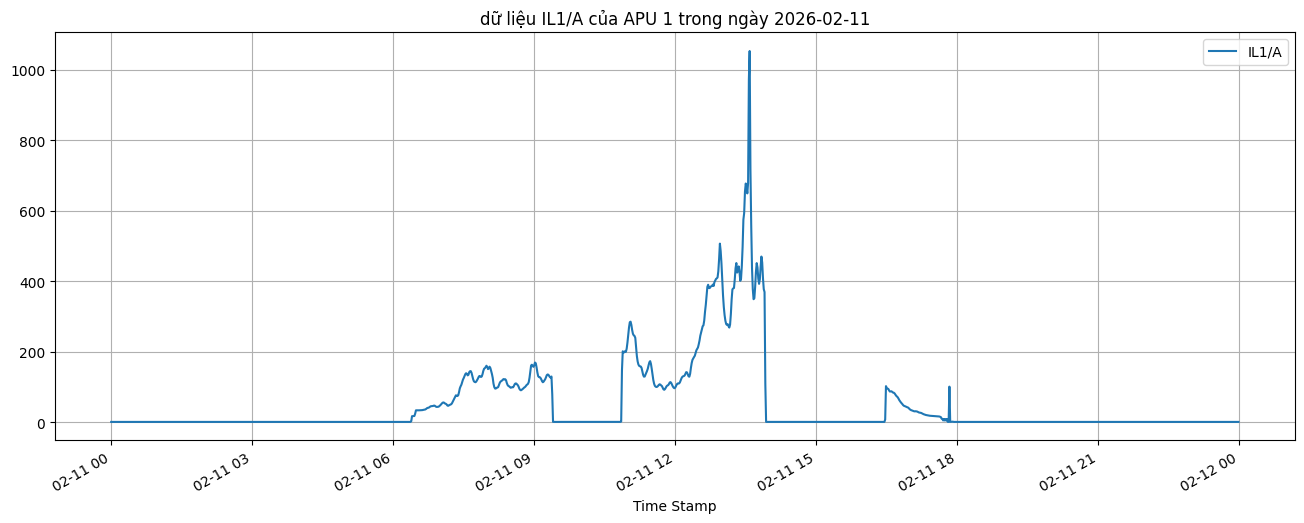

In [105]:

# 2. Sau đó mới chạy lại lệnh vẽ biểu đồ
cols_to_plot = ['IL1/A']
s11_apu1[cols_to_plot].plot(subplots=True, figsize=(16, 6), grid=True)
#plt.ylim(bottom=0)
plt.title("dữ liệu IL1/A của APU 1 trong ngày 2026-02-11")
#plt.ylim(350,390)
plt.show()


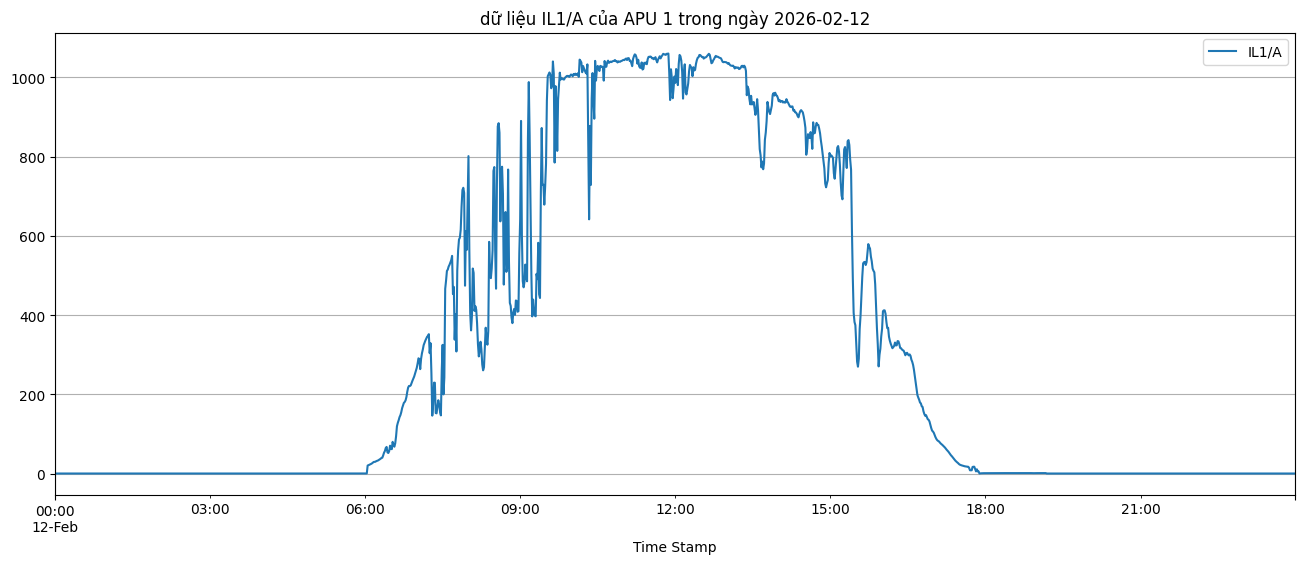

In [104]:

# 2. Sau đó mới chạy lại lệnh vẽ biểu đồ
cols_to_plot = ['IL1/A']
s12_apu1[cols_to_plot].plot(subplots=True, figsize=(16, 6), grid=True)
#plt.ylim(bottom=0)
plt.title("dữ liệu IL1/A của APU 1 trong ngày 2026-02-12")
#plt.ylim(350,390)
plt.show()


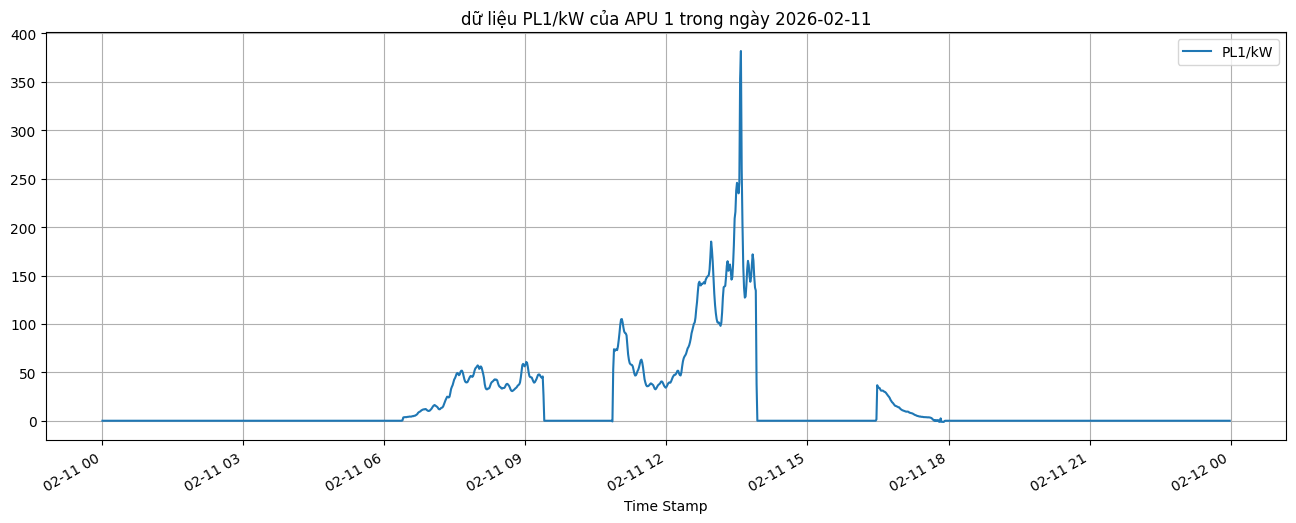

In [106]:

# 2. Sau đó mới chạy lại lệnh vẽ biểu đồ
cols_to_plot = ['PL1/kW']
s11_apu1[cols_to_plot].plot(subplots=True, figsize=(16, 6), grid=True)
#plt.ylim(bottom=0)
plt.title("dữ liệu PL1/kW của APU 1 trong ngày 2026-02-11")
#plt.ylim(350,390)
plt.show()


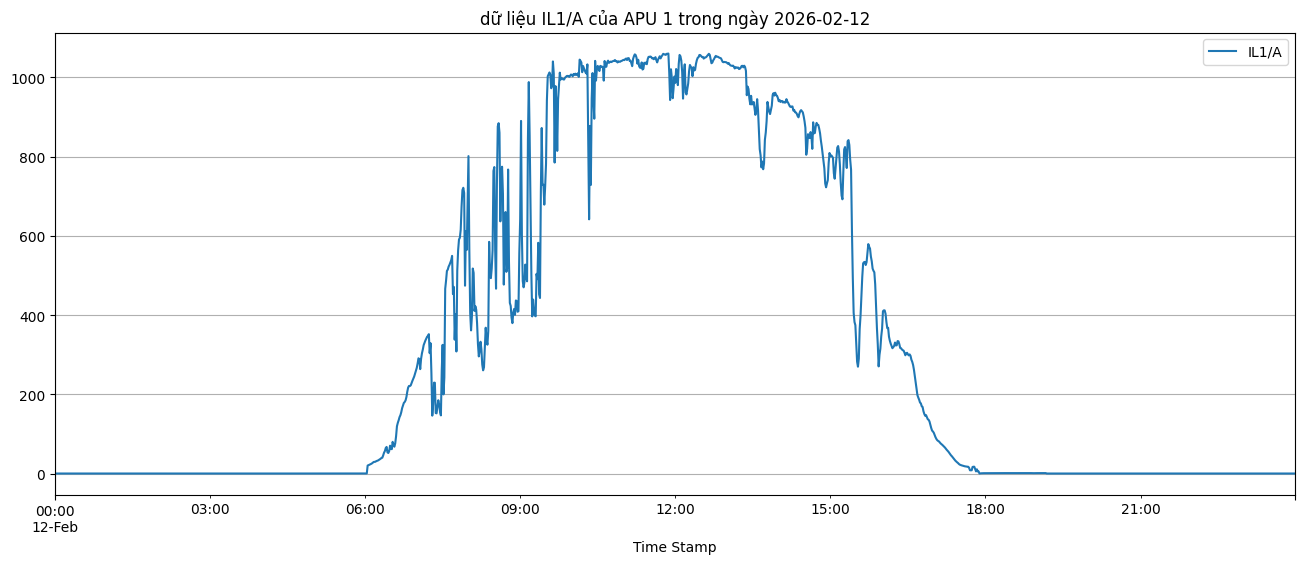

In [107]:

# 2. Sau đó mới chạy lại lệnh vẽ biểu đồ
cols_to_plot = ['IL1/A']
s12_apu1[cols_to_plot].plot(subplots=True, figsize=(16, 6), grid=True)
#plt.ylim(bottom=0)
plt.title("dữ liệu IL1/A của APU 1 trong ngày 2026-02-12")
#plt.ylim(350,390)
plt.show()
